# Módulo 4: Construcción de características

## Tratamiento de categóricos III: Polynomial feature creation

#### Objetivo 

* Comprender cómo es que los modelos de ML pueden consumir categorías y como éstas pasan a ser números.
* Aprender sobre un método poco utilizado pero útil para encontrar relaciones entre variables.

#### Actividad 1
Tomar el dataset `actividad_10,0a` y conforme a los tipos de encoders realizar:
* Polynomial
    * Generar un dataframe de grado 3. 
    * Generar un modelo con este dataframe.
    * Graficar los coeficientes. 

#### Actividad 2
Tomar la base de datos `Automobile_data.csv` de la plataforma y
* Genera un polinomio de grado 3 con las variables numéricas. 
* Separar adecuadamente train y test y de normalizar tus datos.
* Genera un modelo de regresión lineal con estos nuevos sets. 
* Observa coeficientes y responde:
    * ¿Qué interacciones se generan entre las variables que sean igual o más relevantes que las variables iniciales? 
    * Después de responder el punto anterior, ¿se te ocurre alguna variable nueva que pudiera ser generada? 
    


In [17]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.datasets import make_regression
from itertools import combinations
from matplotlib import pyplot as plt
from copy import deepcopy
import os

plt.style.use('ggplot')
%matplotlib inline
seed = 28
path = '.'

### Polynomial feature creation
En clases anteriores y desde el módulo III se ha tratado sobre generación de interacción entre variables.

Dentro de la preparación de este tipo de información está la generación de polinomios. 

Un polinomio de manera general tiene la forma: 


\begin{equation}
    \begin{split}
        f(x) &= \sum_{i=0}^n \beta_i x^i \\
        f(x) &= \beta_0 + \beta_1x + \beta_2x^2 + \cdots + \beta_nx^n
    \end{split} 
\end{equation}

Nosotros al utilizar un dataset tenemos varias variables, algo así: 
\begin{equation}
        f(x, y) = \beta_0 + \beta_1x + \beta_2y
\end{equation}


El objetivo de una creación de polinomios con nuestras variables es generar **interacción** entre nuestros predictores. Suponga que se tienen dos variables y se establece un grado 2 en el polinomio, tendríamos algo así (asumamos que no hay coeficientes para simplificar):

\begin{equation}
        f(x, y) = x + y + x^2 + y^2 + xy
 \end{equation}


Esto nos permitirá descubrir que pueden existir relaciones entre nuestras variables. 

##### Observaciones relevantes: 

* Los features cuadráticos (en este caso) no tienen mucho sentido pues son solo las mismas variables por un escalar. Es mejor droppear estos. 


In [18]:
df = pd.read_csv('actividad_10,1a.csv')

In [19]:
df.head()

,cuartos,distancia_al_centro_km,m2_terreno,monto_recibo_de_luz,precio
0,3.0,28.851679,147.534447,1953.082899,3.424915e+06
1,4.0,25.993369,150.814670,1537.957923,3.896473e+06
2,3.0,34.645559,162.308203,1080.837613,3.735365e+06
3,4.0,12.678020,104.719198,1147.142829,2.714817e+06
4,4.0,23.645491,153.699174,1325.408033,3.771648e+06


Veamos correlaciones de usuarios. 

In [20]:
df.corr()['precio'].sort_values()

monto_recibo_de_luz      -0.010991
cuartos                   0.512086
distancia_al_centro_km    0.563201
m2_terreno                0.590721
precio                    1.000000
Name: precio, dtype: float64

Aparentemente todas las variables salvo "monto_recibo_luz" tienen información relevante para poder estimar el precio de un inmueble. 


Generemos un polinomio a partir de nuestro set.

In [21]:
poly = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)

In [22]:
# Separando predictores de response
response = ['precio']
predictores = [c for c in df if c not in response]

In [23]:
df_poly = pd.DataFrame(poly.fit_transform(df[predictores]))

In [24]:
df_poly.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,3.0,28.851679,147.534447,1953.082899,86.555037,442.603341,5859.248698,4256.616510,56349.720990,288147.005173,12769.849531,169049.162971,864441.015518,8.313525e+06
1,4.0,25.993369,150.814670,1537.957923,103.973476,603.258681,6151.831690,3920.181391,39976.707963,231946.616925,15680.725564,159906.831851,927786.467701,6.029074e+06
2,3.0,34.645559,162.308203,1080.837613,103.936676,486.924608,3242.512838,5623.258336,37446.222741,175428.810454,16869.775009,112338.668222,526286.431361,6.077829e+06
3,4.0,12.678020,104.719198,1147.142829,50.712081,418.876792,4588.571316,1327.632101,14543.499888,120127.877003,5310.528403,58173.999553,480511.508010,1.522984e+06
4,4.0,23.645491,153.699174,1325.408033,94.581965,614.796696,5301.632133,3634.292487,31339.924162,203714.119919,14537.169948,125359.696647,814856.479675,4.816920e+06


Observemos las variables generadas: 

In [25]:
train_x, test_x, train_y, test_y = train_test_split(
    df_poly,
    df[response],
    test_size=0.2,
    random_state=seed
)

In [26]:
means = train_x.mean()
stds = train_x.std()

In [27]:
train_x_norm = (train_x - means) / stds
test_x_norm = (test_x - means) / stds

In [28]:
model = LinearRegression()

In [29]:
model.fit(train_x_norm, train_y)

LinearRegression()

In [30]:
train_scores = model.predict(train_x_norm)
test_scores = model.predict(test_x_norm)

In [31]:
# Errores
error1 = mean_absolute_percentage_error(y_pred=test_scores, y_true=test_y)
error1

0.03480400647299646

<Axes: >

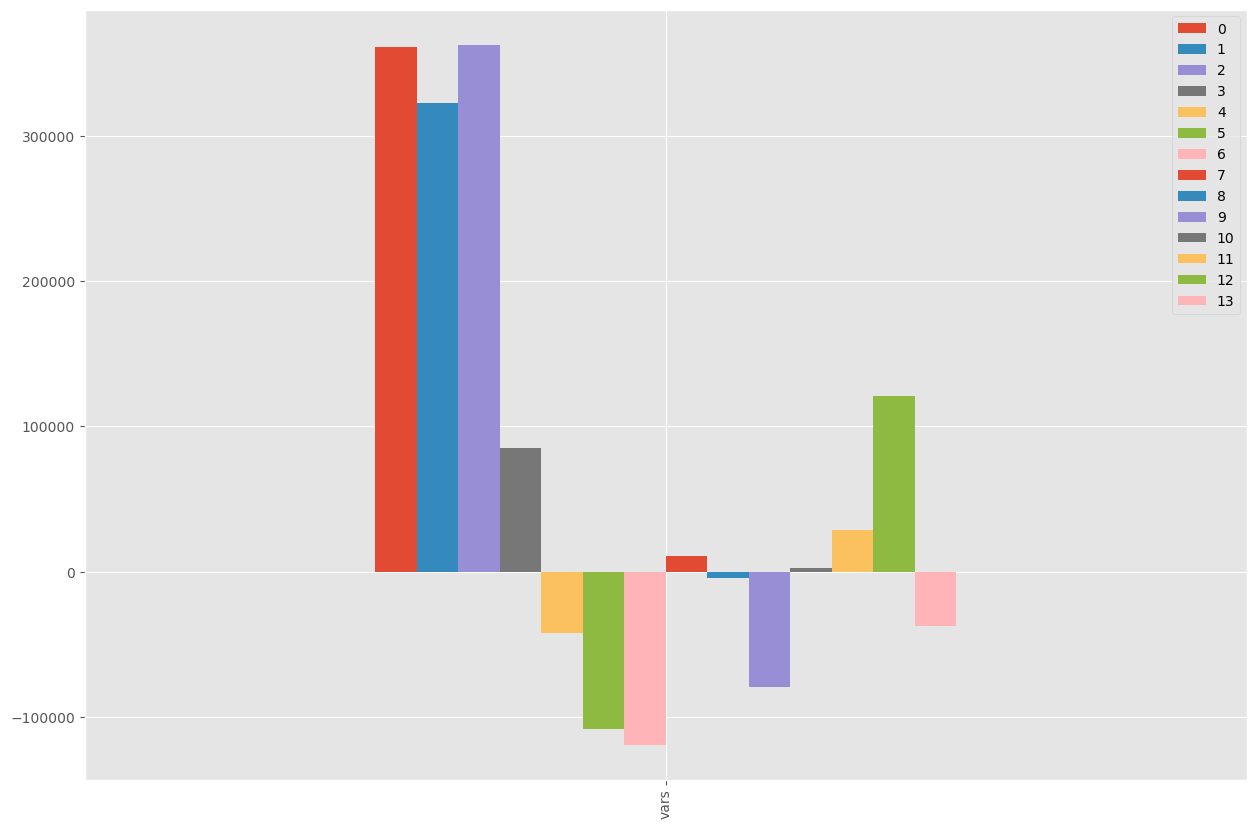

In [32]:
pd.DataFrame(dict(zip(train_x_norm.columns, model.coef_[0])), index=['vars']).plot(kind='bar', figsize=(15,10))